#  Notebook d’analyse — Negative Prompts



Ce notebook regroupe les tableaux, graphiques et analyses utilisés dans le rapport final.



Il est organisé en suivant la structure du rapport :

- **IV. Analyse des résultats et reproduction**

- **V. Analyse critique et pistes d’amélioration**

###  Initialisation de l’environnement

In [41]:
## Clônage du repot

!git clone https://github.com/wydad-fulbert/NegativePrompt.git
%cd NegativePrompt

Cloning into 'NegativePrompt'...
remote: Enumerating objects: 684, done.
remote: Counting objects: 100% (167/167), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 684 (delta 77), reused 1 (delta 1), pack-reused 517 (from 2)
Receiving objects: 100% (684/684), 5.36 MiB | 9.50 MiB/s, done.
Resolving deltas: 100% (317/317), done.
/content/NegativePrompt/NegativePrompt/NegativePrompt/NegativePrompt


In [37]:
#IMPORTS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# **IV. Analyse des résultats et reproduction**

In [47]:
##CHARGEMENT DES DONNES

path = "results/reproduction/"
t5 = pd.read_csv(path + "results_t5.csv")
llama = pd.read_csv(path + "results_llama2.csv")
vicuna = pd.read_csv(path + "results_vicuna.csv")

In [48]:
df_all = pd.concat([t5, llama, vicuna])

In [49]:
pivot_stats = df_all.groupby(['model', 'stimulus'])['score'].mean().unstack()
print("--- Moyennes des scores EM par modèle et stimulus ---")
print(pivot_stats)

--- Moyennes des scores EM par modèle et stimulus ---
stimulus  0 (Baseline)      1     10      5
model                                      
llama2           0.385  0.330  0.300  0.372
t5               0.213  0.220  0.215  0.216
vicuna           0.254  0.226  0.264  0.286


In [50]:
pivot_stats.to_csv("stats_globales.csv")

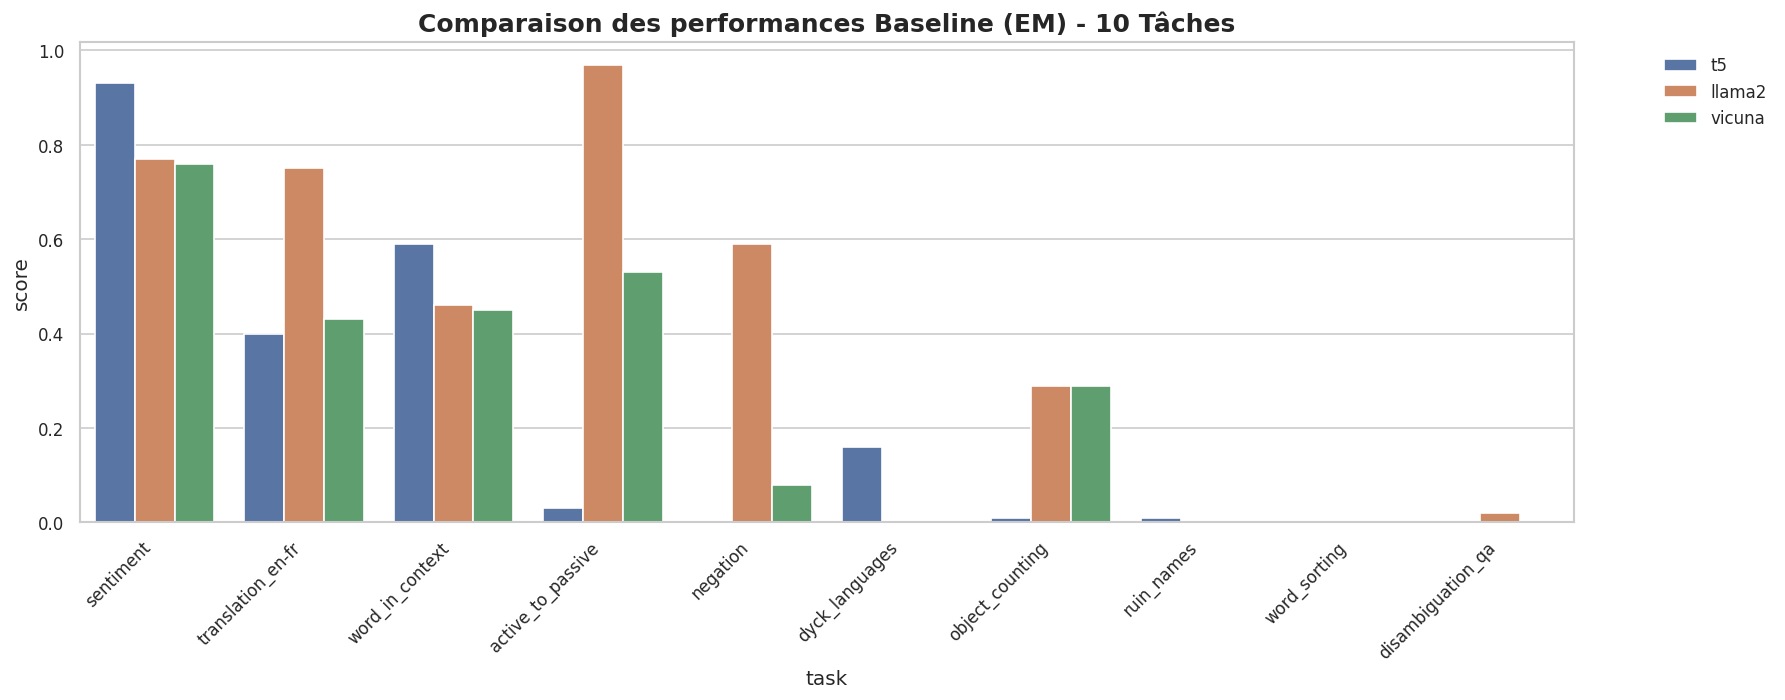

In [51]:
baseline = df_all[df_all['stimulus'] == '0 (Baseline)']

plt.figure(figsize=(15, 6))
sns.barplot(data=baseline, x='task', y='score', hue='model')
plt.title("Comparaison des performances Baseline (EM) - 10 Tâches")
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("comparaison_baselines.png")
plt.show()

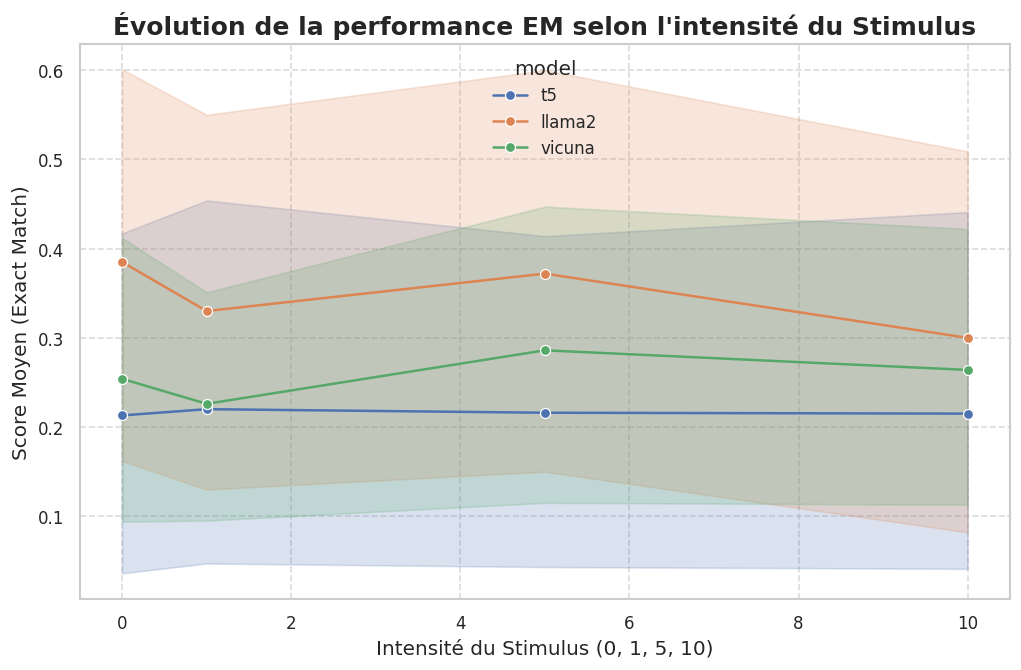

In [52]:
df_all['stim_val'] = df_all['stimulus'].apply(lambda x: 0 if 'Baseline' in str(x) else int(x))

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_all, x='stim_val', y='score', hue='model', marker='o')
plt.title("Évolution de la performance EM selon l'intensité du Stimulus")
plt.xlabel("Intensité du Stimulus (0, 1, 5, 10)")
plt.ylabel("Score Moyen (Exact Match)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("evolution_stimuli_models.png")
plt.show()

--- Comparaison EM vs BLEU (Traduction) ---
                 em_normalized      bleu
model  stimulus                         
llama2 0                  0.00  0.005849
       1                  0.00  0.006629
       5                  0.00  0.005621
       10                 0.00  0.006904
t5     0                  0.22  0.039122
       1                  0.20  0.037061
       5                  0.21  0.038839
       10                 0.21  0.037344
vicuna 0                  0.43  0.078952
       1                  0.35  0.063934
       5                  0.36  0.070010
       10                 0.18  0.038392


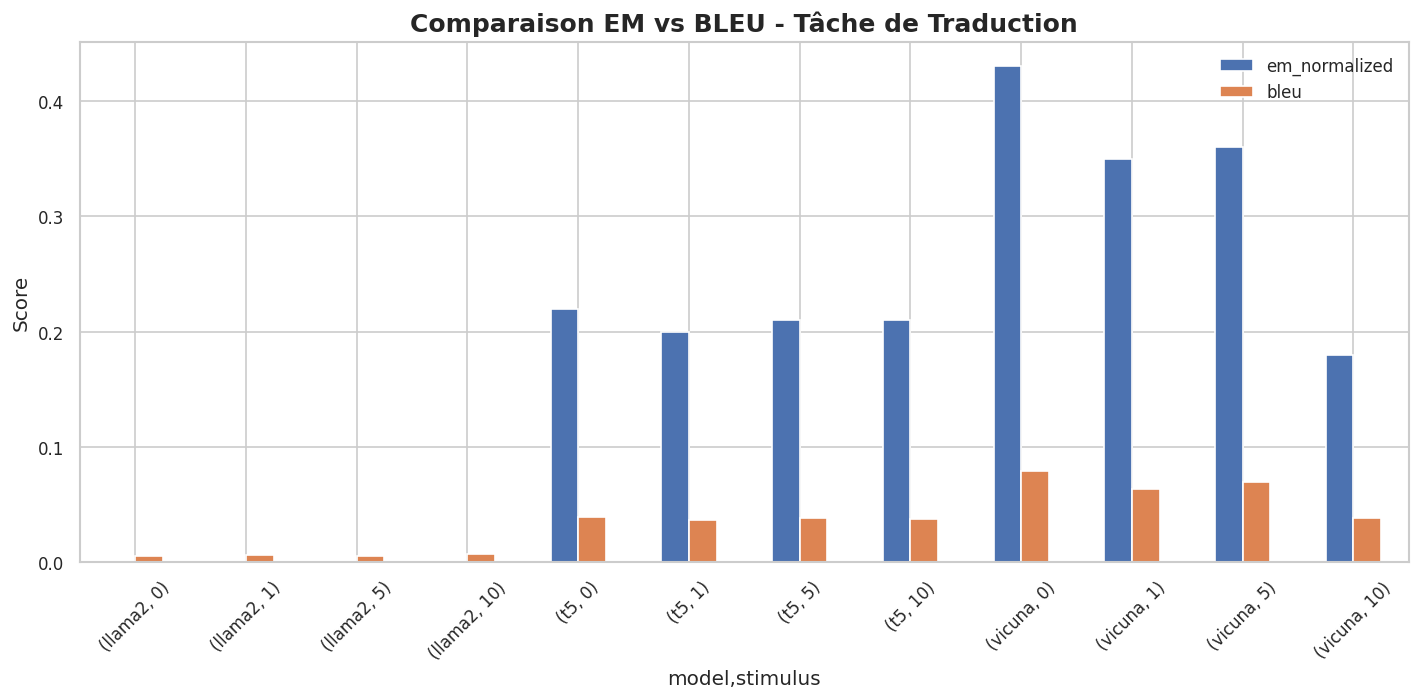

In [53]:
# Chargement du fichier détaillé
df_bleu = pd.read_csv("results/reproduction/results_bleu_3models_detailed.csv")

# Comparaison EM vs BLEU sur la tâche de traduction
translation_stats = df_bleu[df_bleu['task'] == 'translation_en-fr'].groupby(['model', 'stimulus'])[['em_normalized', 'bleu']].mean()

print("--- Comparaison EM vs BLEU (Traduction) ---")
print(translation_stats)

# Visualisation pour prouver que BLEU est plus "juste"
translation_stats.plot(kind='bar', figsize=(12, 6))
plt.title("Comparaison EM vs BLEU - Tâche de Traduction")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("comparaison_em_bleu.png")
plt.show()

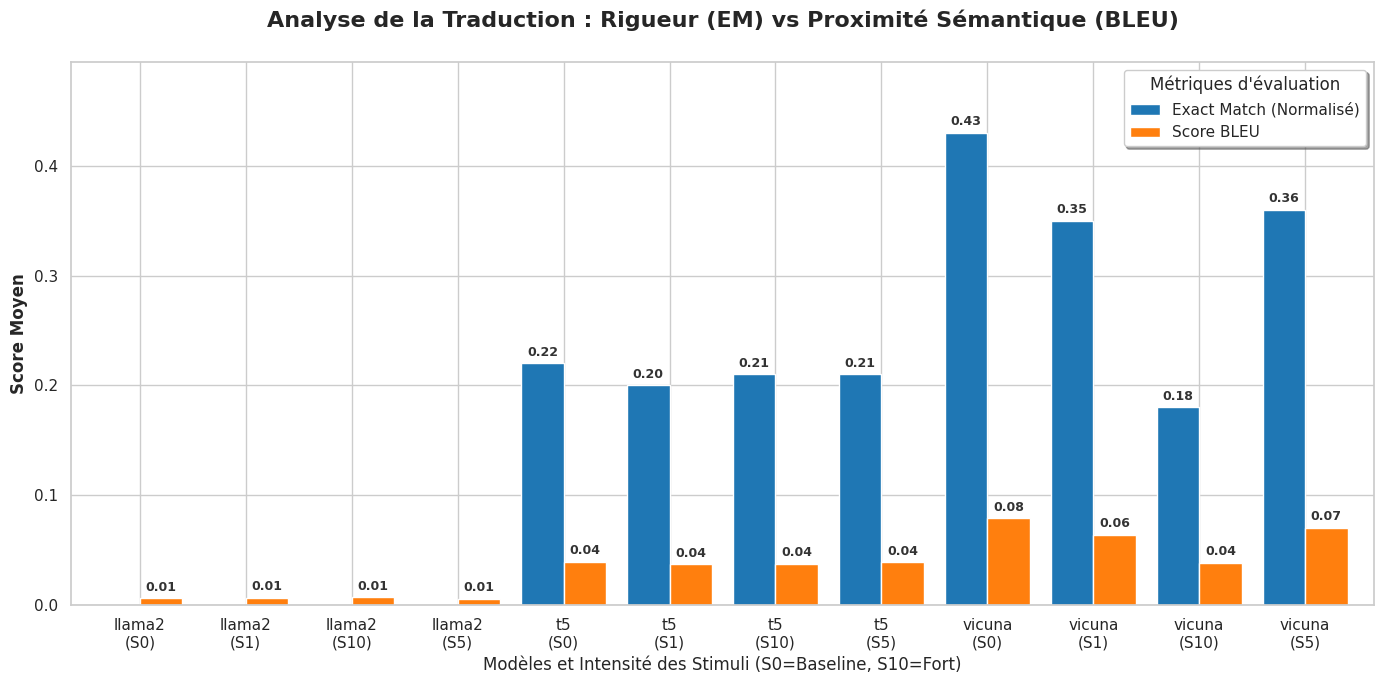

✅ Graphique 'comparaison_em_bleu_final.png' généré avec succès.


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuration esthétique
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# 2. Chargement des données
try:
    df_bleu = pd.read_csv("results/reproduction/results_bleu_3models_detailed.csv")
except:
    df_bleu = pd.read_csv("results_bleu_3models_detailed.csv")

# 3. Préparation des données pour la traduction
df_trans = df_bleu[df_bleu['task'] == 'translation_en-fr'].copy()

# Nettoyage des noms de stimuli pour un affichage plus propre (ex: "0 (Baseline)" -> "0")
df_trans['stimulus_label'] = df_trans['stimulus'].apply(lambda x: str(x).split(' ')[0])

# Calcul des moyennes par modèle et stimulus
stats = df_trans.groupby(['model', 'stimulus_label'])[['em_normalized', 'bleu']].mean().reset_index()

# Création d'un label combiné pour l'axe X : "Modèle (S0)"
stats['x_label'] = stats['model'] + "\n(S" + stats['stimulus_label'] + ")"

# 4. Génération du graphique
fig, ax = plt.subplots(figsize=(14, 7))

# Définition explicite des couleurs : EM en bleu, BLEU en orange
# On utilise l'indexation de pandas pour garder les barres groupées par label
stats.set_index('x_label')[['em_normalized', 'bleu']].plot(
    kind='bar',
    ax=ax,
    color=['#1f77b4', '#ff7f0e'], # Bleu et Orange
    width=0.8,
    edgecolor='white',
    linewidth=1
)

# 5. Personnalisation
plt.title("Analyse de la Traduction : Rigueur (EM) vs Proximité Sémantique (BLEU)",
          fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Score Moyen", fontsize=12, fontweight='bold')
plt.xlabel("Modèles et Intensité des Stimuli (S0=Baseline, S10=Fort)", fontsize=12)

# Amélioration de la légende
plt.legend(["Exact Match (Normalisé)", "Score BLEU"],
           title="Métriques d'évaluation",
           frameon=True, shadow=True, loc='upper right')

# Affichage des valeurs sur les barres pour la précision
for p in ax.patches:
    if p.get_height() > 0: # N'affiche que si le score est > 0
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=9, fontweight='bold', color='#333333')

plt.xticks(rotation=0) # Garde les labels horizontaux pour la lisibilité
plt.ylim(0, stats[['em_normalized', 'bleu']].values.max() * 1.15) # Donne de l'espace en haut
plt.tight_layout()

# 6. Sauvegarde
plt.savefig("comparaison_em_bleu_final.png", dpi=300)
plt.show()

print("✅ Graphique 'comparaison_em_bleu_final.png' généré avec succès.")

In [55]:
# Code pour mesurer si le modèle "répète" le stimulus négatif
distraction_keywords = ["mundane", "boredom", "seen others", "efficiently", "good at this"]

def check_distracted(text):
    if pd.isna(text): return False
    return any(word in str(text).lower() for word in distraction_keywords)

# Utilisation du fichier détaillé (BLEU) pour voir les prédictions réelles
df_bleu['is_distracted'] = df_bleu['prediction'].apply(check_distracted)
distraction_stats = df_bleu.groupby(['model', 'stimulus'])['is_distracted'].mean() * 100

print("--- Pourcentage de réponses 'distraites' par le stimulus ---")
print(distraction_stats)

--- Pourcentage de réponses 'distraites' par le stimulus ---
model   stimulus
llama2  0            0.000000
        1            6.666667
        5            7.333333
        10          18.666667
t5      0            0.000000
        1            0.333333
        5            0.000000
        10           0.333333
vicuna  0            0.000000
        1            8.000000
        5            4.333333
        10           4.666667
Name: is_distracted, dtype: float64


In [56]:
# Code pour grouper les tâches par famille
task_mapping = {
    'sentiment': 'Sémantique', 'translation_en-fr': 'Sémantique',
    'word_in_context': 'Sémantique', 'active_to_passive': 'Sémantique', 'negation': 'Sémantique',
    'dyck_languages': 'Logique', 'word_sorting': 'Logique',
    'object_counting': 'Raisonnement', 'ruin_names': 'Raisonnement', 'disambiguation_qa': 'Raisonnement'
}
df_all['category'] = df_all['task'].map(task_mapping)

cat_analysis = df_all.groupby(['model', 'stim_val', 'category'])['score'].mean().unstack(level=1)
print("--- Résilience par catégorie de tâches ---")
print(cat_analysis)

--- Résilience par catégorie de tâches ---
stim_val                   0         1         5         10
model  category                                            
llama2 Logique       0.000000  0.000000  0.015000  0.000000
       Raisonnement  0.103333  0.060000  0.086667  0.023333
       Sémantique    0.708000  0.624000  0.686000  0.586000
t5     Logique       0.080000  0.100000  0.100000  0.095000
       Raisonnement  0.006667  0.006667  0.006667  0.000000
       Sémantique    0.390000  0.396000  0.388000  0.392000
vicuna Logique       0.000000  0.000000  0.000000  0.000000
       Raisonnement  0.096667  0.090000  0.073333  0.080000
       Sémantique    0.450000  0.398000  0.528000  0.480000


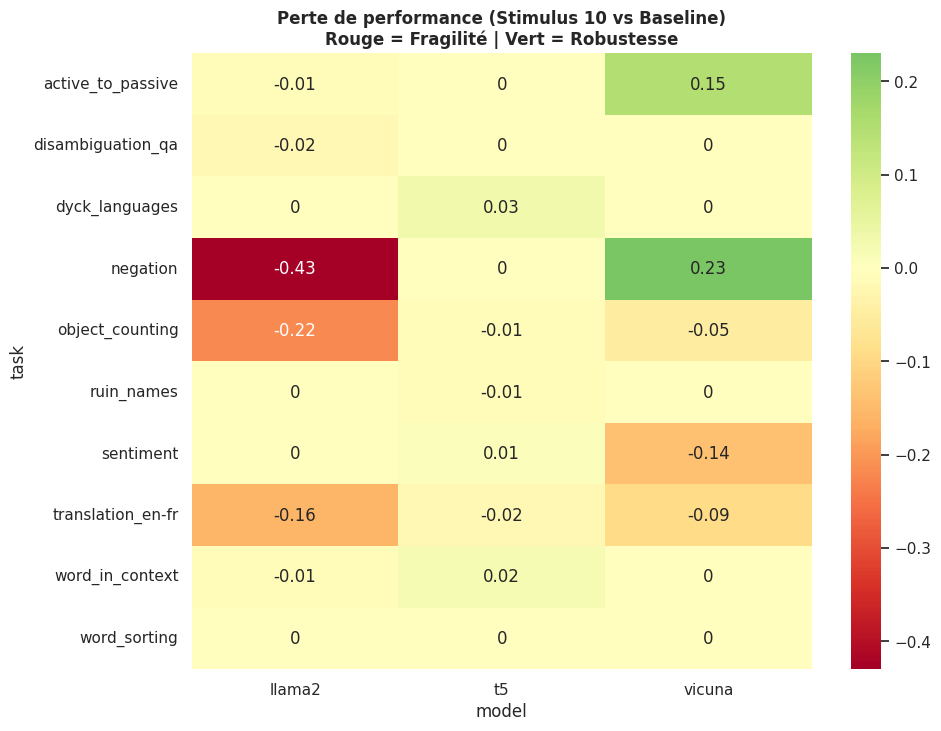

In [57]:
# Code pour générer la Heatmap de dégradation
pivot_0 = df_all[df_all['stim_val'] == 0].pivot(index='task', columns='model', values='score')
pivot_10 = df_all[df_all['stim_val'] == 10].pivot(index='task', columns='model', values='score')
degradation = pivot_10 - pivot_0

import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(degradation, annot=True, cmap="RdYlGn", center=0)
plt.title("Perte de performance (Stimulus 10 vs Baseline)\nRouge = Fragilité | Vert = Robustesse")
plt.savefig("heatmap_fragilite.png")

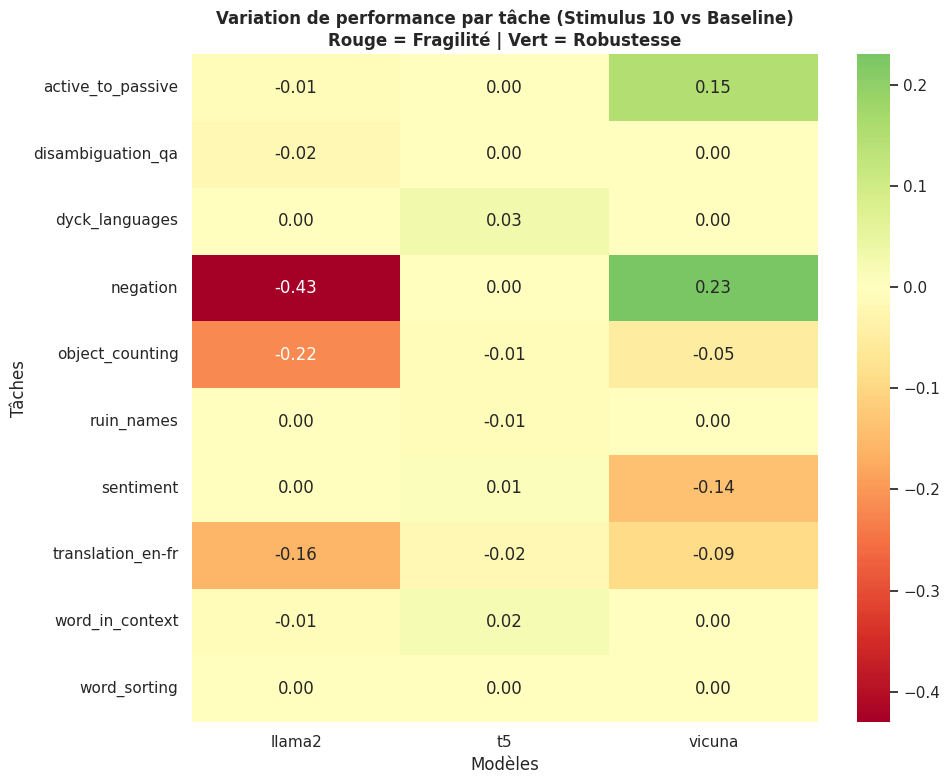

In [58]:

# 3. Calculer la différence entre Baseline (0) et Stimulus 10
# On pivote pour avoir les tâches en index et les stimuli en colonnes
pivot_df = df_all.pivot_table(index=['model', 'task'], columns='stimulus', values='score')

# Calcul de la variation (S10 - Baseline)
# Note : adapter le nom de la colonne '0 (Baseline)' si nécessaire
baseline_col = '0 (Baseline)'
pivot_df['delta'] = pivot_df['10'] - pivot_df[baseline_col]

# 4. Préparation de la Heatmap
heatmap_data = pivot_df['delta'].unstack(level=0)

# 5. Affichage
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="RdYlGn", center=0, fmt=".2f")
plt.title("Variation de performance par tâche (Stimulus 10 vs Baseline)\nRouge = Fragilité | Vert = Robustesse")
plt.ylabel("Tâches")
plt.xlabel("Modèles")
plt.tight_layout()
plt.savefig("heatmap_variation_taches.png")
plt.show()

# **V. Analyses critique et piste d'amélioration**

In [72]:
## CHARGEMENT DES DONNES

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

t5np = pd.read_csv("results/improvements/results_final_np_t5.csv")
llama2np = pd.read_csv("results/improvements/results_final_np_llama2.csv")
vicunanp = pd.read_csv("results/improvements/results_final_np_vicuna.csv")
mistral = pd.read_csv("results/improvements/results_mistral_baseline_np.csv")
lora = pd.read_csv("results/improvements/results_t5_lora_eval_fixed.csv")

t5np["model"] = "T5"
llama2np["model"] = "Llama2"
vicunanp["model"] = "Vicuna"
mistral["model"] = "Mistral"



### GÉNÉRATION AUTOMATIQUE DE NEGATIVE PROMPTS

In [62]:
t5_v3 = t5np[t5np["condition"].isin(["baseline", "np01", "np05", "np10", "np_generated"])].copy()



tableau_t5_v3 = t5_v3.pivot_table(

    index=["task", "metric"],

    columns="condition",

    values="score"

)



tableau_t5_v3["gain_vs_baseline"] = tableau_t5_v3["np_generated"] - tableau_t5_v3["baseline"]

tableau_t5_v3.round(2)

,condition,baseline,np01,np05,np10,np_generated,gain_vs_baseline
task,metric,,,,,,
active_to_passive,bleu,0.14,0.11,0.11,0.11,0.17,0.03
disambiguation_qa,em,0.00,0.00,0.00,0.00,0.07,0.07
dyck_languages,em,0.53,0.47,0.57,0.50,0.53,0.00
negation,em,0.00,0.00,0.00,0.00,0.00,0.00
object_counting,em,0.27,0.27,0.27,0.30,0.30,0.03
ruin_names,bleu,0.19,0.20,0.18,0.18,0.21,0.01
sentiment,em,0.90,0.90,0.90,0.90,0.90,0.00
translation_en-fr,bleu,0.08,0.09,0.08,0.08,0.08,-0.00
word_in_context,em,0.00,0.00,0.00,0.00,0.00,0.00


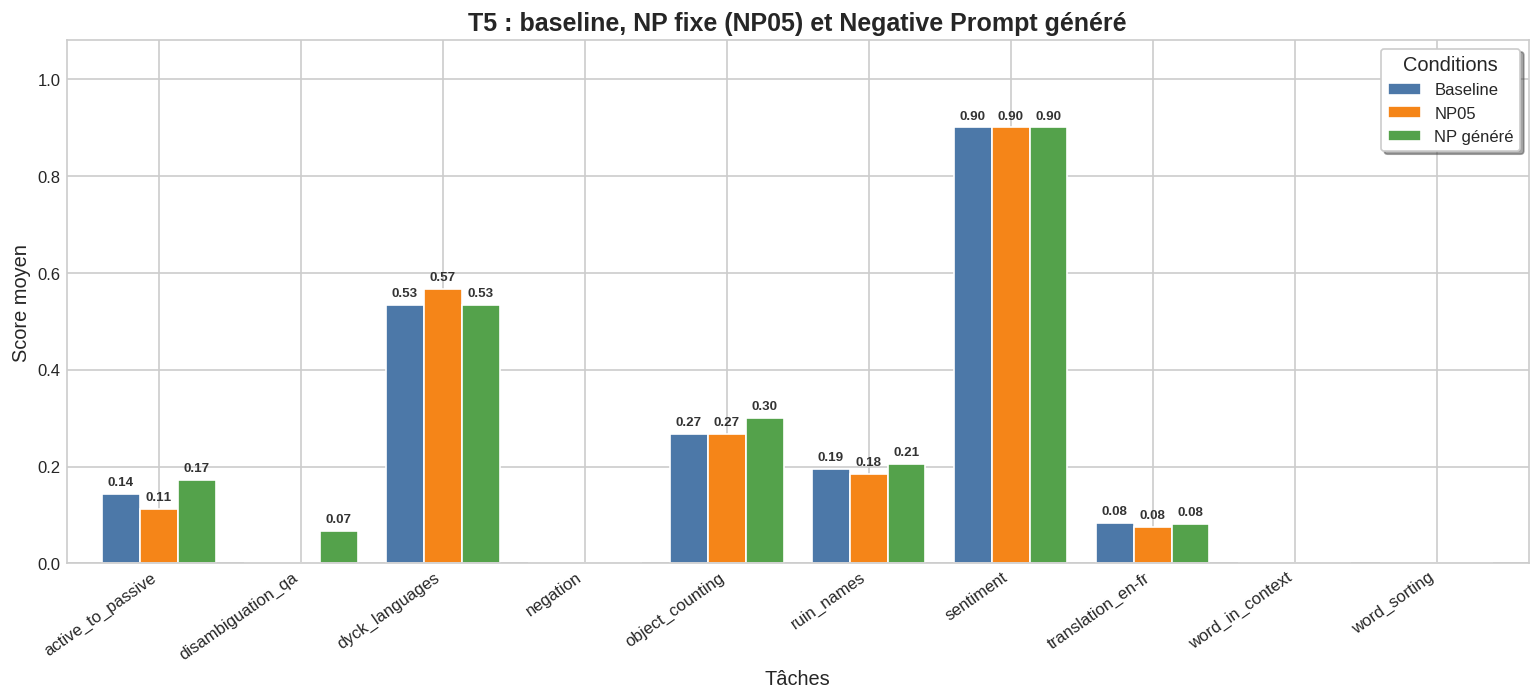

In [63]:
t5_graph = t5np[t5np["condition"].isin(["baseline", "np05", "np_generated"])].copy()



pivot_t5_graph = t5_graph.pivot_table(

    index="task",

    columns="condition",

    values="score"

)



fig, ax = plt.subplots(figsize=(13, 6))



pivot_t5_graph[["baseline", "np05", "np_generated"]].plot(

    kind="bar",

    ax=ax,

    color=["#4C78A8", "#F58518", "#54A24B"],

    width=0.8,

    edgecolor="white",

    linewidth=1

)



plt.title("T5 : baseline, NP fixe (NP05) et Negative Prompt généré")

plt.ylabel("Score moyen")

plt.xlabel("Tâches")



plt.legend(

    ["Baseline", "NP05", "NP généré"],

    title="Conditions",

    frameon=True,

    shadow=True,

    loc="upper right"

)



for p in ax.patches:

    if p.get_height() > 0:

        ax.annotate(

            f"{p.get_height():.2f}",

            (p.get_x() + p.get_width() / 2., p.get_height()),

            ha="center",

            va="center",

            xytext=(0, 7),

            textcoords="offset points",

            fontsize=8,

            fontweight="bold",

            color="#333333"

        )



plt.xticks(rotation=35, ha="right")

plt.ylim(0, max(pivot_t5_graph.max()) * 1.2)

plt.tight_layout()

plt.savefig("graphique_t5_np_generated.png", dpi=300)

plt.show()

#### TABLEAU T5 / LLAMA2 / VICUNA SUR NP GENERATED

In [71]:
df_models_npgen = pd.concat([t5np, llama2np, vicunanp], ignore_index=True)

df_models_npgen = df_models_npgen[df_models_npgen["condition"] == "np_generated"].copy()



tableau_npgen_models = df_models_npgen.pivot_table(

    index=["task", "metric"],

    columns="model",

    values="score"

)
tableau_npgen_models.round(2)

,model,Llama2,T5,Vicuna
task,metric,,,
active_to_passive,bleu,0.15,0.17,0.01
disambiguation_qa,em,0.00,0.07,0.00
dyck_languages,em,0.00,0.53,0.00
negation,em,0.00,0.00,0.00
object_counting,em,0.00,0.30,0.00
ruin_names,bleu,0.01,0.21,0.00
sentiment,em,0.00,0.90,0.00
translation_en-fr,bleu,0.00,0.08,0.00
word_in_context,em,0.00,0.00,0.00


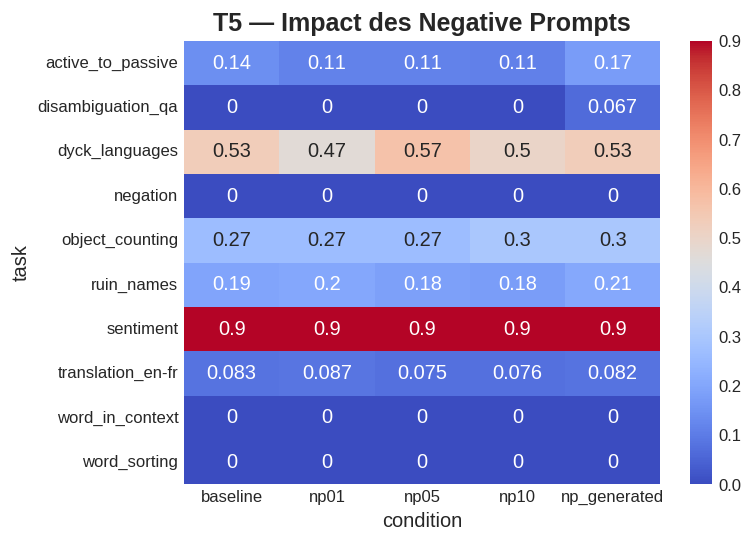

In [69]:
pivot = t5np.pivot_table(
    index="task",
    columns="condition",
    values="score"
)

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("T5 — Impact des Negative Prompts")
plt.show()

### EXTENSION À UN MODÈLE SUPPLÉMENTAIRE : MISTRAL

#### TABLEAU MISTRAL

In [65]:
tableau_mistral = mistral.pivot_table(

    index=["task", "metric"],

    columns="condition",

    values="score"

)
tableau_mistral.round(2)

,condition,baseline,np01,np05,np10
task,metric,,,,
active_to_passive,bleu,1.00,0.97,1.00,1.00
disambiguation_qa,em,0.00,0.00,0.00,0.00
dyck_languages,em,0.40,0.43,0.30,0.53
negation,em,0.77,0.77,0.80,0.77
object_counting,em,0.37,0.37,0.27,0.30
ruin_names,bleu,0.12,0.13,0.10,0.12
sentiment,em,0.83,0.87,0.83,0.87
translation_en-fr,bleu,0.14,0.12,0.13,0.12
word_in_context,em,0.00,0.00,0.00,0.00


#### GRAPHIQUE MISTRAL

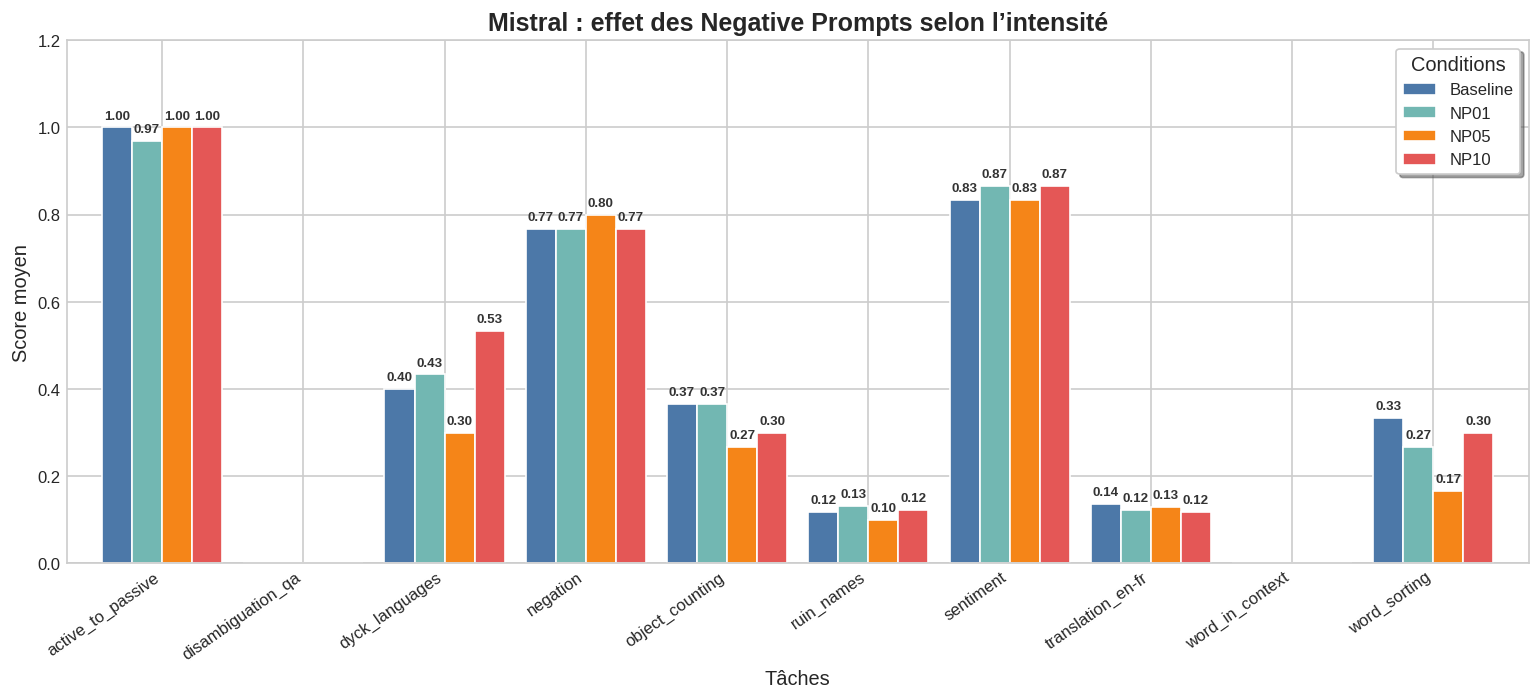

In [66]:
pivot_mistral_graph = mistral.pivot_table(

    index="task",

    columns="condition",

    values="score"

)
fig, ax = plt.subplots(figsize=(13, 6))
pivot_mistral_graph[["baseline", "np01", "np05", "np10"]].plot(

    kind="bar",

    ax=ax,

    color=["#4C78A8", "#72B7B2", "#F58518", "#E45756"],

    width=0.85,

    edgecolor="white",

    linewidth=1

)
plt.title("Mistral : effet des Negative Prompts selon l’intensité")
plt.ylabel("Score moyen")
plt.xlabel("Tâches")
plt.legend(

    ["Baseline", "NP01", "NP05", "NP10"],

    title="Conditions",

    frameon=True,

    shadow=True,

    loc="upper right"

)
for p in ax.patches:

    if p.get_height() > 0:

        ax.annotate(

            f"{p.get_height():.2f}",

            (p.get_x() + p.get_width() / 2., p.get_height()),

            ha="center",

            va="center",

            xytext=(0, 7),

            textcoords="offset points",

            fontsize=8,

            fontweight="bold",

            color="#333333"

        )
plt.xticks(rotation=35, ha="right")
plt.ylim(0, max(pivot_mistral_graph.max()) * 1.2)
plt.tight_layout()
plt.savefig("graphique_mistral_np.png", dpi=300)
plt.show()

### TENTATIVE DE FINE-TUNING LÉGER PAR LORA

##### TABLEAU LORA

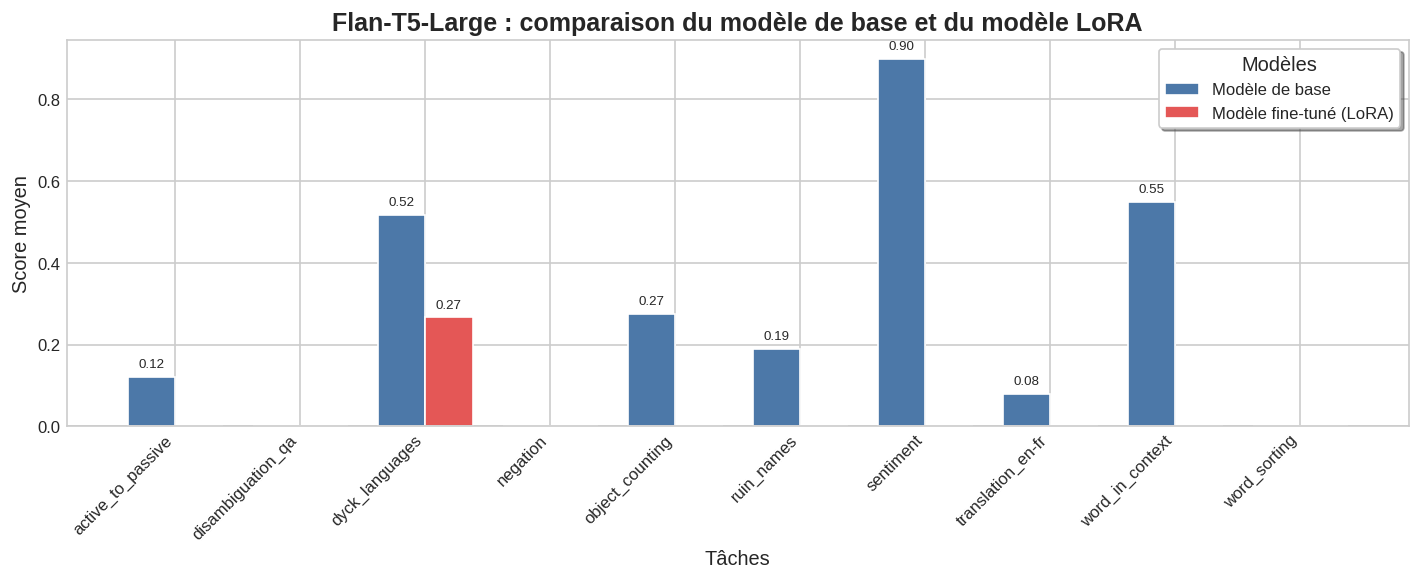

In [67]:
lora = pd.read_csv("results/improvements/results_t5_lora_eval_fixed.csv")

resume_lora = lora.groupby("task")[["score_base", "score_lora"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(resume_lora))
width = 0.38

ax.bar(
    [i - width/2 for i in x],
    resume_lora["score_base"],
    width=width,
    label="Modèle de base",
    color="#4C78A8",
    edgecolor="white",
    linewidth=1
)

ax.bar(
    [i + width/2 for i in x],
    resume_lora["score_lora"],
    width=width,
    label="Modèle fine-tuné (LoRA)",
    color="#E45756",
    edgecolor="white",
    linewidth=1
)

ax.set_title("Flan-T5-Large : comparaison du modèle de base et du modèle LoRA")
ax.set_ylabel("Score moyen")
ax.set_xlabel("Tâches")
ax.set_xticks(list(x))
ax.set_xticklabels(resume_lora["task"], rotation=45, ha="right")

ax.legend(title="Modèles", frameon=True, shadow=True)

for bars in ax.containers:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(
                f"{h:.2f}",
                (bar.get_x() + bar.get_width() / 2, h),
                ha="center",
                va="bottom",
                fontsize=8,
                xytext=(0, 4),
                textcoords="offset points"
            )

plt.tight_layout()
plt.savefig("graphique_lora_resume.png", dpi=300)
plt.show()

In [68]:
tableau_lora = lora[["task", "condition", "score_base", "score_lora"]].copy()
tableau_lora.round(2)

,task,condition,score_base,score_lora
0,active_to_passive,baseline,0.14,0.00
1,active_to_passive,np01,0.11,0.00
2,active_to_passive,np05,0.11,0.00
3,active_to_passive,np10,0.11,0.00
4,disambiguation_qa,baseline,0.00,0.00
5,disambiguation_qa,np01,0.00,0.00
6,disambiguation_qa,np05,0.00,0.00
7,disambiguation_qa,np10,0.00,0.00
8,dyck_languages,baseline,0.53,0.27
9,dyck_languages,np01,0.47,0.27
